In [1]:
import polars as pl

# 1. Cargar datos (Polars lee Excel, pero CSV es más rápido si ya lo convertiste)
# Si usas el excel directo: read_excel
df = pl.read_parquet("..\\data\\raw\\dataset_depresion.parquet")

# 2. Vistazo General
print(df.glimpse())

# 3. Análisis de Longitud y Clases
analisis = df.with_columns(
    pl.col("text").str.split(" ").list.len().alias("n_palabras")
).group_by("manual_classification").agg([
    pl.len().alias("total_muestras"),
    pl.col("n_palabras").mean().alias("promedio_palabras"),
    pl.col("n_palabras").min().alias("min_palabras"),
    pl.col("n_palabras").max().alias("max_palabras")
])

print(analisis)

# 4. Filtrar textos "basura" (muy cortos)
textos_cortos = df.filter(
    pl.col("text").str.split(" ").list.len() < 10
)
print(f"Textos con menos de 10 palabras: {len(textos_cortos)}")

Rows: 1136
Columns: 11
$ id                    <i64> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10
$ beck_range            <i64> 5, 17, 0, 12, 7, 9, 10, 1, 3, 4
$ depression_level      <i64> 1, 3, 1, 2, 1, 1, 1, 1, 1, 1
$ text                  <str> 'Me siento bien, un poco cansado creo es lo habitual o normal después de los fines de semana.Aunque los días parecen ser iguales por qué no hay días de salida o visitas o salir a platicar con los amigos solo por teléfono y las charlas se han vuelto borras o no hay algún tema de interés creo que me he dedicado más a ver videos o televisión o estar en las redes sociales la mayor parte del tiempo viendo que comparten de vez en cuando las noticias para saber cuándo volveremos a salir .\nEn mi vida creo que va bien un poco aburrida ya que yo era de salir los fines de semana de fiesta los domingos a jugar fútbol y ente semana salía un par de días a dar la vuelta y convivir con mis amigos.Sigo estudiando y entregando tareas aunque aveces es desesperante por qué n

In [3]:
import polars as pl
import re

def limpiar_texto(texto):
    if texto is None: return ""
    # 1. Pasar a minúsculas
    t = texto.lower()
    # 2. Quitar saltos de línea
    t = t.replace("\n", " ")
    # 3. Quitar frases de encuesta (ejemplo básico)
    t = t.replace("respondiendo a la pregunta", "")
    # 4. Quitar caracteres especiales o puntuación excesiva
    t = re.sub(r'[^\w\s]', '', t) 
    return t

# Aplicar en Polars
df_clean = df.with_columns(
    pl.col("text").map_elements(limpiar_texto).alias("text_clean")
)

In [4]:
# 2. Vistazo General
print(df_clean.glimpse())

# 3. Análisis de Longitud y Clases
analisis = df_clean.with_columns(
    pl.col("text").str.split(" ").list.len().alias("n_palabras")
).group_by("manual_classification").agg([
    pl.len().alias("total_muestras"),
    pl.col("n_palabras").mean().alias("promedio_palabras"),
    pl.col("n_palabras").min().alias("min_palabras"),
    pl.col("n_palabras").max().alias("max_palabras")
])

print(analisis)

Rows: 1136
Columns: 12
$ id                    <i64> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10
$ beck_range            <i64> 5, 17, 0, 12, 7, 9, 10, 1, 3, 4
$ depression_level      <i64> 1, 3, 1, 2, 1, 1, 1, 1, 1, 1
$ text                  <str> 'Me siento bien, un poco cansado creo es lo habitual o normal después de los fines de semana.Aunque los días parecen ser iguales por qué no hay días de salida o visitas o salir a platicar con los amigos solo por teléfono y las charlas se han vuelto borras o no hay algún tema de interés creo que me he dedicado más a ver videos o televisión o estar en las redes sociales la mayor parte del tiempo viendo que comparten de vez en cuando las noticias para saber cuándo volveremos a salir .\nEn mi vida creo que va bien un poco aburrida ya que yo era de salir los fines de semana de fiesta los domingos a jugar fútbol y ente semana salía un par de días a dar la vuelta y convivir con mis amigos.Sigo estudiando y entregando tareas aunque aveces es desesperante por qué n

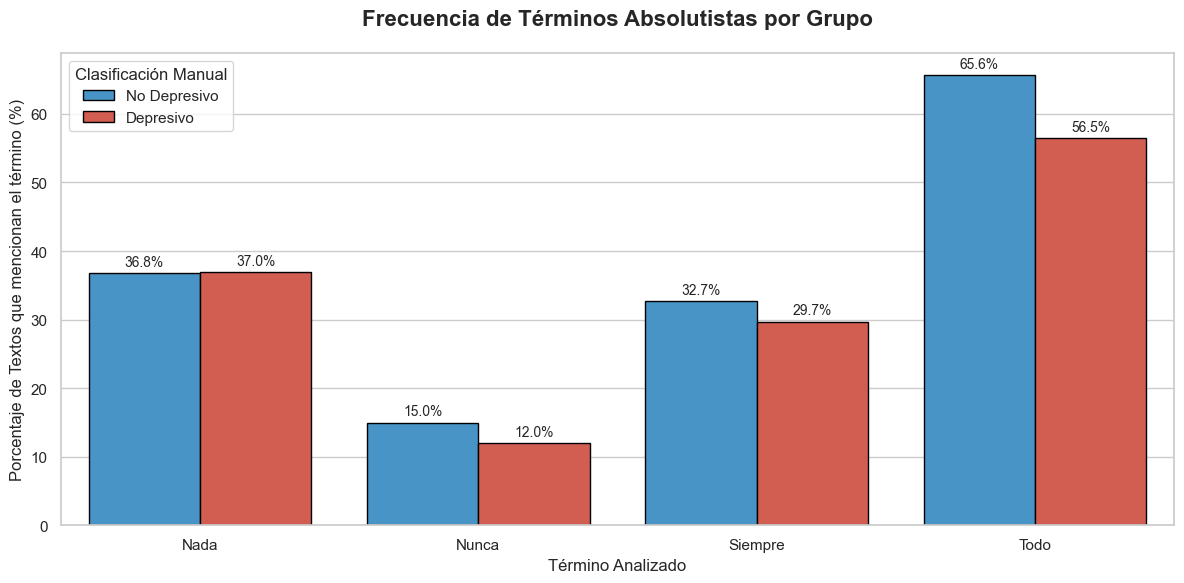

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar datos (Asegúrate de tener tu df cargado)
df = pd.read_parquet("..\\data\\raw\\dataset_depresion.parquet")

# 2. Definir palabras clave y etiquetas
# keywords = ['pandemia', 'cuarentena', 'covid', 'virus', 'confinamiento', 'encierro', 'contingencia']
keywords = ['triste', 'llorar', 'soledad', 'dormir', 'cansado', 'felicidad', 'alegre', 'ganas']
# keywords = ['nada', 'nunca', 'siempre', 'todo']

# 3. Preparar los datos para el gráfico
data_plot = []

for word in keywords:
    for clase in [0, 1]:
        # Filtrar por clase
        subset = df[df['manual_classification'] == clase]
        
        # Calcular porcentaje de textos que contienen la palabra
        # Usamos str.contains para buscar la palabra (case insensitive)
        conteo = subset['text'].str.lower().str.contains(word).sum()
        total = len(subset)
        porcentaje = (conteo / total) * 100
        
        label_clase = "Depresivo" if clase == 1 else "No Depresivo"
        
        data_plot.append({
            'Palabra': word.capitalize(),
            'Porcentaje': porcentaje,
            'Grupo': label_clase
        })

df_plot = pd.DataFrame(data_plot)

# 4. Configurar el estilo del gráfico (Estilo académico)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Crear el gráfico de barras agrupado
ax = sns.barplot(
    data=df_plot,
    x='Palabra',
    y='Porcentaje',
    hue='Grupo',
    palette={'No Depresivo': '#3498db', 'Depresivo': '#e74c3c'}, # Azul y Rojo clínico
    edgecolor="black" # Borde para mayor definición
)

# 5. Añadir etiquetas y títulos
plt.title('Frecuencia de Términos Absolutistas por Grupo', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Porcentaje de Textos que mencionan el término (%)', fontsize=12)
plt.xlabel('Término Analizado', fontsize=12)
plt.legend(title='Clasificación Manual')

# Añadir el valor exacto encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10)

# Ajustar diseño
plt.tight_layout()

# 6. Mostrar y Guardar
plt.savefig('analisis_absolutista.png', dpi=300) # Guardar en alta resolución para la tesis
plt.show()